## Read and Setup Dataset

In [1]:
import pandas as pd
fp = "../data/generated_biomass_MW_series.csv"
df = pd.read_csv(fp)

In [2]:
df.columns = ["time", "signal"]
df

,time,signal
0,2018-04-12 06:00:00+00:00,381.0
1,2018-04-12 07:00:00+00:00,383.0
2,2018-04-12 08:00:00+00:00,385.0
3,2018-04-12 09:00:00+00:00,378.0
4,2018-04-12 10:00:00+00:00,379.0
...,...,...
2155,2018-07-11 01:00:00+00:00,313.0
2156,2018-07-11 02:00:00+00:00,314.0
2157,2018-07-11 03:00:00+00:00,320.0
2158,2018-07-11 04:00:00+00:00,325.0


## Prepare for SSA
1. Define Window
2. Run SSA
3. Analyze Eigen Value Plot

In [3]:
series = df.signal
series.index = df.time

In [4]:
from ssalib import SingularSpectrumAnalysis
wdw = 24
ssa = SingularSpectrumAnalysis(series, window=wdw)

In [5]:
ssa.decompose()

SingularSpectrumAnalysis(timeseries=<Series shape=(2160,)>, window=24, svd_matrix='SSAMatrixType.BK_TRAJECTORY', svd_solver='numpy_standard', standardize=True)

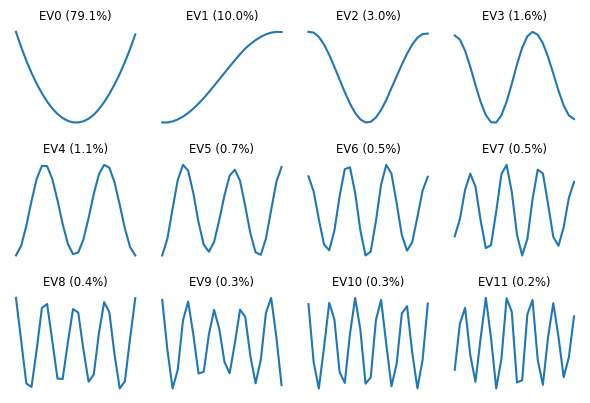

In [6]:
fig, axes = ssa.plot(kind='vectors')

## Apply Grouping

In [7]:
ssa.reconstruct(groups={'Trend': [0, 1,2], 'Seasonal': [3,4,5,6,7,8], "residuals":[9,10,11]})

SingularSpectrumAnalysis(timeseries=<Series shape=(2160,)>, window=24, svd_matrix='SSAMatrixType.BK_TRAJECTORY', svd_solver='numpy_standard', standardize=True)

## Residual Analysis

ssa["residuals"]

In [8]:
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson

In [9]:

# 3. Perform the Durbin-Watson test
dw_statistic = durbin_watson(ssa["residuals"].values)

print(f"Durbin-Watson statistic: {dw_statistic}")

Durbin-Watson statistic: 1.5012581611229514


<Axes: ylabel='Density'>

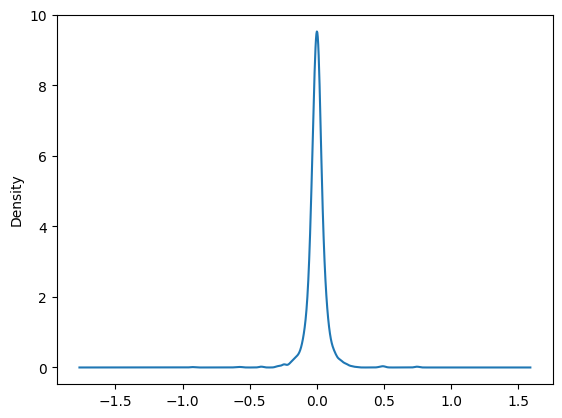

In [10]:
ssa["residuals"].plot.kde()

1. The residuals do not explain a lot of variation in the signal
2. Change point detection on the residuals, run with the assumption that we don't know the the change points apriori, with a
penalty $\beta = 2 . \log(N)$ suggests there are no change points in the noise. The implication is that unexplained variance does not change over the observation period. The change points of interest are in the trend and seasonal component.

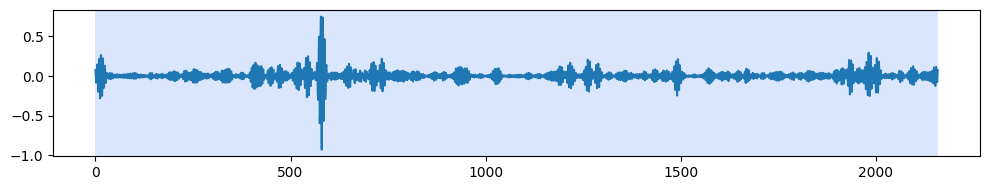

In [11]:
import ruptures as rpt
import matplotlib.pyplot as plt
from math import log
algo = rpt.Pelt(model="rbf").fit(ssa["residuals"].values)
rec_pen = 2*log(ssa["residuals"].shape[0],2)
# 3. Predict the change points
# The 'pen' parameter controls the sensitivity (higher penalty, fewer change points)
result = algo.predict(pen=rec_pen)

# 4. Display the results (optional, requires matplotlib)
rpt.display(ssa["residuals"].values, result)
plt.show()

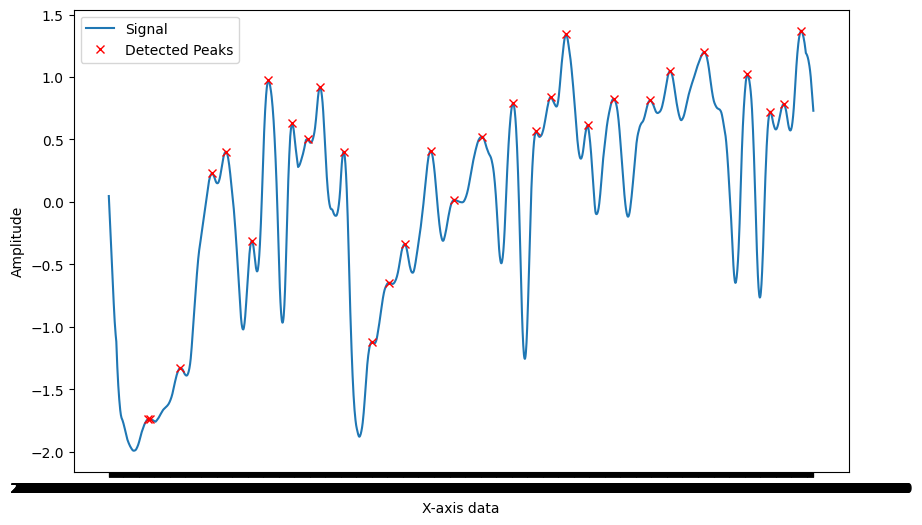

In [12]:
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
the_signal = ssa[0].values
x = series.index.values
peaks_indices, properties = find_peaks(the_signal)

# 3. Plot the results (optional, but helpful for visualization)
plt.figure(figsize=(10, 6))
plt.plot(x, the_signal, label='Signal')
plt.plot(x[peaks_indices], the_signal[peaks_indices], 'x', color='red', label='Detected Peaks')
plt.xlabel('X-axis data')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

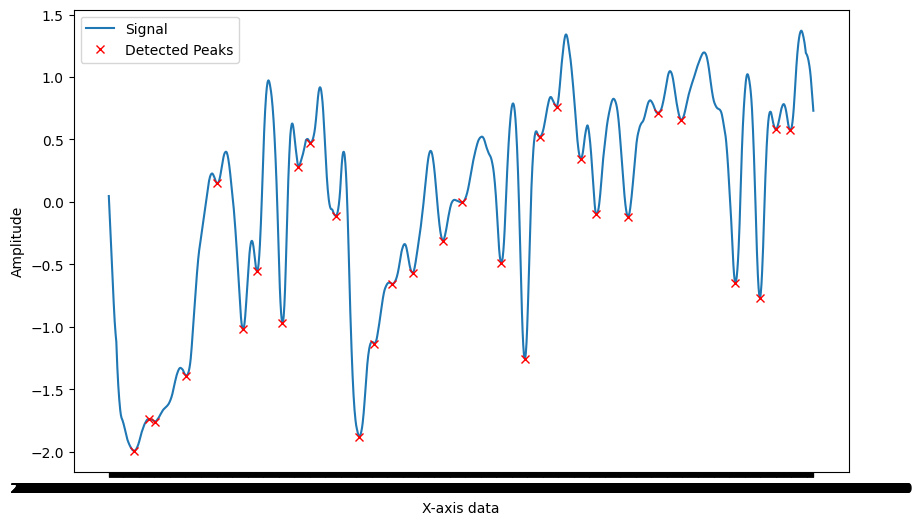

In [13]:

the_signal = -ssa[0].values
x = series.index.values
peaks_indices, properties = find_peaks(the_signal)
the_signal = ssa[0].values

# 3. Plot the results (optional, but helpful for visualization)
plt.figure(figsize=(10, 6))
plt.plot(x, the_signal, label='Signal')
plt.plot(x[peaks_indices], the_signal[peaks_indices], 'x', color='red', label='Detected Peaks')
plt.xlabel('X-axis data')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

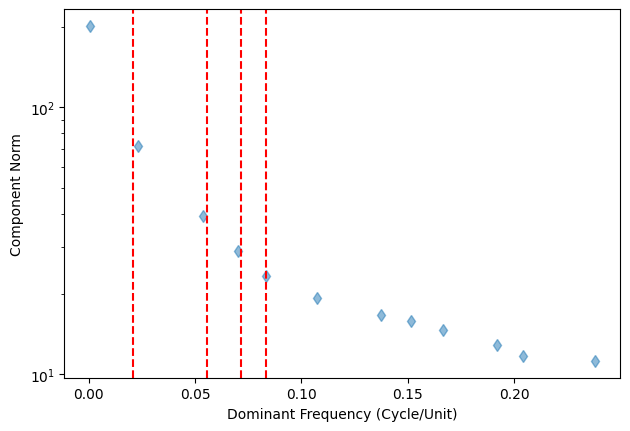

In [14]:
fig, ax = ssa.plot(
    n_components=12,
    rank_by='freq',
    marker='d', ls='none', alpha=.5
)
ax.axvline(x=(1/12), color='r', linestyle='--', label='Vertical line at x=1/12')
ax.axvline(x=(1/14), color='r', linestyle='--', label='Vertical line at x=1/14')
ax.axvline(x=(1/18), color='r', linestyle='--', label='Vertical line at x=1/18')
ax.axvline(x=(1/48), color='r', linestyle='--', label='Vertical line at x=1/48')

## Knowledge Base Logging

In [15]:
from kmds.ontology.kmds_ontology import *
from kmds.tagging.tag_types import ExploratoryTags
kaw = KnowledgeExtractionExperimentationWorkflow("biomass_per_hour_generation_4_year_data_SPAIN", namespace=onto)

In [16]:
model_observations = " This dataset is the hourly generation data for various power sources. This analysis looks at power generation from biomass. It can be\
downloaded from the Kaggle (https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather) website. A review of the raw dataset may leave the analyst with a sense of hopelessness,\
however, as we will show, algorithmic techniques can be applied to summarize this dataset effectively"
model_observations += "1. Singular Spectrum Analysis was used to summarize the variation observed in power generations 2.\
There is a trend and seasonal component. The trend component accounts for about 94 percent and the seasonal component accounts for about 3.5 percent of variablity"
model_observations += " The change points in this 4 year period can be identified by a peak finding algorithm that captures the end of trend cycles.\
SSA is based on SVD and therefore frequency components associated with the decomposition can also be identified. The reader is urged to refer to \
this notebook for the implementation details."
model_observations += " You will need some trial and error to find the noise term. The test for serial correlation can help here. The Duribin\
watson test can be used to check if the residuals have serial correlation. A test statistic in the range 1.5 to 2.5 indicates a lack of\
serial correlation and is generally considered acceptable to conclude that there is no major first order correlation within the residuals."


In [17]:
from kmds.ontology.intent_types import IntentType
exp_obs_list = []
observation_count :int = 1
e1 = ExploratoryObservation(namespace=onto)

In [18]:
from google import genai
from google.genai import types
import os
from dotenv import load_dotenv

load_dotenv()   

True

In [19]:

# Get AI response using the Gemini model
API_KEY = os.getenv("GEMINI_API_KEY")
client = genai.Client(api_key=API_KEY)
your_input = f"Can you summarize the following model observations succintly and return it as plain text string: {model_observations}"
response = client.models.generate_content(
model="gemini-2.5-flash",
contents=your_input,)

#response = model.generate_content(user_input)
ai_response = response.text

In [20]:
ai_response

'This analysis uses Singular Spectrum Analysis (SSA) on hourly biomass power generation data to summarize its variation. The dataset exhibits a strong trend component, accounting for approximately 94% of variability, and a seasonal component, contributing about 3.5%. Change points, marking the end of trend cycles, are identifiable using peak finding algorithms. SSA, being SVD-based, also allows for the identification of frequency components. The Durbin-Watson test (statistic 1.5-2.5) is recommended to identify the noise term by checking for a lack of serial correlation in residuals.'

In [21]:

e1.finding = ai_response
e1.finding_sequence = observation_count
e1.exploratory_observation_type = ExploratoryTags.DATA_QUALITY_OBSERVATION.value
e1.intent = IntentType.DATA_UNDERSTANDING.value
exp_obs_list.append(e1)

In [22]:
observation_count += 1
e2 = ExploratoryObservation(namespace=onto)
e2.finding = "Just like that, a 4 year history of power generation from biomass sources has been analyzed."
e2.finding_sequence = observation_count
e2.exploratory_observation_type = ExploratoryTags.DATA_QUALITY_OBSERVATION.value
e2.intent = IntentType.DATA_UNDERSTANDING.value
exp_obs_list.append(e2)
kaw.has_exploratory_observations = exp_obs_list

In [23]:
from owlready2 import *
from kmds.utils.path_utils import get_package_kb_path
KNOWLEDGE_BASE = "../data/kmds/biomass_power_analysis.xml"
onto.save(file=KNOWLEDGE_BASE, format="rdfxml")